In [1]:
!pip install yfinance pandas numpy matplotlib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from itertools import combinations
import yfinance as yf

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.facecolor':'#0f0f0f', 'axes.facecolor':'#1a1a1a',
    'axes.edgecolor':'#333',      'text.color':'#e8e8e8',
    'axes.labelcolor':'#e8e8e8',  'xtick.color':'#888',
    'ytick.color':'#888',         'grid.color':'#2a2a2a',
    'grid.linestyle':'--',
})

In [2]:
TICKERS = [
    'BBCA.JK', 'BBRI.JK', 'BMRI.JK', 'BBNI.JK',
]

START_DATE      = '2020-01-01'
END_DATE        = 'today'
INTERVAL        = '1d'

CORR_THRESHOLD  = 0.60
ZSCORE_WINDOW   = 30
ENTRY_THRESHOLD = 2.0
EXIT_THRESHOLD  = 0.5
TOP_N_PAIRS     = 6
COINT_PVALUE    = 0.05
BROKER_FEE      = 0.003

In [3]:
if END_DATE == 'today':
    END_DATE = pd.Timestamp.today().strftime('%Y-%m-%d')

raw    = yf.download(TICKERS, start=START_DATE, end=END_DATE,
                     interval=INTERVAL, auto_adjust=True, progress=True)
prices = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw[['Close']]
prices = prices.dropna(axis=1, thresh=int(0.8*len(prices))).ffill().dropna()

print(f'\n✅ {prices.shape[0]} hari  |  {prices.shape[1]} saham valid')
print(f'   {prices.index[0].date()} s/d {prices.index[-1].date()}')
prices.tail(3)

[*********************100%***********************]  4 of 4 completed


✅ 1485 hari  |  4 saham valid
   2020-01-02 s/d 2026-02-27


Ticker,BBCA.JK,BBNI.JK,BBRI.JK,BMRI.JK
Date,,,,
2026-02-25,7325.0,4500.0,3970.0,5300.0
2026-02-26,7300.0,4460.0,3950.0,5325.0
2026-02-27,7175.0,4400.0,3910.0,5275.0


In [5]:
# kalman hedge ratio
def kalman_hedge_ratio(pa, pb):
    n  = len(pa)
    pa = pa.values.astype(float)
    pb = pb.values.astype(float)
    theta = np.array([1.0, 0.0])
    P = np.eye(2) * 1.0
    Q = np.eye(2) * 1e-4
    R = 1.0
    beta_out      = np.zeros(n)
    intercept_out = np.zeros(n)
    for t in range(n):
        F      = np.array([pb[t], 1.0])
        P_pred = P + Q
        innov  = pa[t] - F @ theta
        S      = F @ P_pred @ F + R
        K      = P_pred @ F / S
        theta  = theta + K * innov
        P      = (np.eye(2) - np.outer(K, F)) @ P_pred
        beta_out[t]      = theta[0]
        intercept_out[t] = theta[1]
    return beta_out, intercept_out


def compute_spread(pa, pb, beta_s, ic_s):
    return pa - beta_s * pb - ic_s


def compute_zscore(sp, w):
    return (sp - sp.rolling(w).mean()) / sp.rolling(w).std()


def generate_long_only_signals(zs, entry, ex):
    pos, p = [], 0
    for z in zs:
        if np.isnan(z): pos.append(0); continue
        if p == 0:
            if z <= -entry: p = 1    # BUY — A lagi murah
        elif z >= -ex:  p = 0        # JUAL — A sudah balik normal
        pos.append(p)
    df = pd.DataFrame({'zscore': zs.values, 'position': pos}, index=zs.index)
    df['signal'] = df['position'].diff().fillna(0)
    return df


def adf_pvalue(series):
    s  = np.array(series, dtype=float)
    s  = s[~np.isnan(s)]
    n  = len(s)
    ds = np.diff(s)
    sl = s[:-1]
    X  = np.column_stack([sl, np.ones(len(sl))])
    b  = np.linalg.lstsq(X, ds, rcond=None)[0]
    resid = ds - X @ b
    var   = resid @ resid / (n - 2)
    se    = np.sqrt(var * np.linalg.inv(X.T @ X)[0, 0])
    t     = b[0] / se if se > 0 else 0
    if   t < -3.96: return 0.01
    elif t < -3.41: return 0.025
    elif t < -2.86: return 0.05
    elif t < -2.57: return 0.10
    elif t < -2.23: return 0.20
    else:           return 1.0


def engle_granger_pvalue(pa, pb):
    """Engle-Granger cointegration test manual."""
    def resid(x, y):
        X = np.column_stack([y.values, np.ones(len(y))])
        b = np.linalg.lstsq(X, x.values, rcond=None)[0]
        return x.values - X @ b
    return min(adf_pvalue(resid(pa, pb)), adf_pvalue(resid(pb, pa)))

In [6]:
log_ret     = np.log(prices / prices.shift(1)).dropna()
corr_matrix = log_ret.corr()
tickers     = list(prices.columns)

print('COINTEGRATION TEST — Engle-Granger')
print('='*65)
print(f'{"Pair":<22} {"Korelasi":>10} {"p-value":>10} {"Status":>15}')
print('-'*65)

coint_results = []
for a, b in combinations(tickers, 2):
    corr = corr_matrix.loc[a, b]
    if abs(corr) < CORR_THRESHOLD:
        continue
    pval     = engle_granger_pvalue(prices[a], prices[b])
    is_coint = pval < COINT_PVALUE
    status   = '✅ COINTEGRATED' if is_coint else '❌ Tidak lolos'
    la, lb   = a.replace('.JK',''), b.replace('.JK','')
    print(f'{la+" / "+lb:<22} {corr:>10.4f} {pval:>10.4f} {status:>15}')
    if is_coint:
        coint_results.append((a, b, corr, pval))

coint_results.sort(key=lambda x: x[3])
print('='*65)
print(f'\n✅ {len(coint_results)} pair lolos cointegration test')
if not coint_results:
    print('⚠️  Tidak ada yang lolos. Coba turunkan CORR_THRESHOLD.')

COINTEGRATION TEST — Engle-Granger
Pair                     Korelasi    p-value          Status
-----------------------------------------------------------------
BBNI / BBRI                0.6920     0.0500   ❌ Tidak lolos
BBNI / BMRI                0.7053     0.0100  ✅ COINTEGRATED
BBRI / BMRI                0.6764     0.1000   ❌ Tidak lolos

✅ 1 pair lolos cointegration test


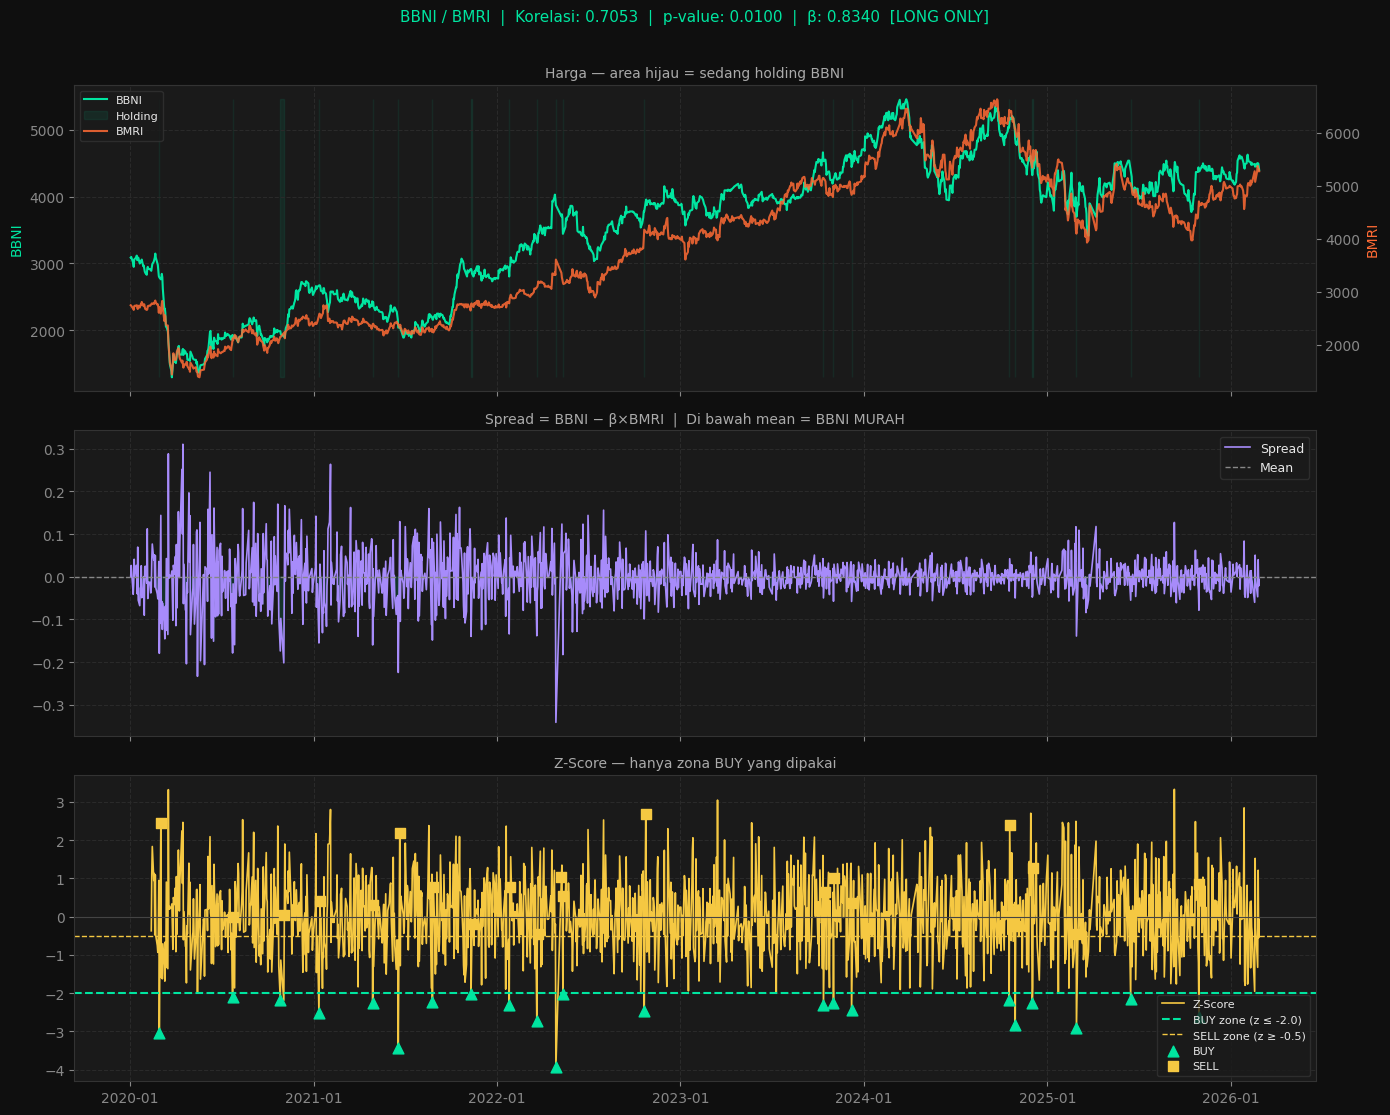

  Z-Score skrg : -0.077
  Status       : ⚪ FLAT
  Total trade  : 22 kali BUY, 22 kali SELL



In [7]:
#analysis

results  = {}
top_pairs = coint_results[:TOP_N_PAIRS] if coint_results else []

if not top_pairs:
    print('⚠️  Tidak ada pair yang bisa dianalisis.')

for ta, tb, corr, pval in top_pairs:
    pa  = prices[ta]; pb = prices[tb]
    idx = pa.index.intersection(pb.index)
    pa, pb = pa.loc[idx], pb.loc[idx]
    la, lb = ta.replace('.JK',''), tb.replace('.JK','')

    beta_arr, ic_arr = kalman_hedge_ratio(pa, pb)
    beta_s = pd.Series(beta_arr, index=pa.index)
    ic_s   = pd.Series(ic_arr,   index=pa.index)

    sp  = compute_spread(pa, pb, beta_s, ic_s)
    zs  = compute_zscore(sp, ZSCORE_WINDOW)
    sig = generate_long_only_signals(zs, ENTRY_THRESHOLD, EXIT_THRESHOLD)

    hr_today = float(beta_s.iloc[-1])
    ic_today = float(ic_s.iloc[-1])

    results[(ta, tb)] = {
        'hr': hr_today, 'ic': ic_today,
        'hr_series': beta_s, 'ic_series': ic_s,
        'sp': sp, 'zs': zs, 'sig': sig,
        'corr': corr, 'pval': pval,
        'pa': pa, 'pb': pb
    }

    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
    fig.suptitle(
        f'{la} / {lb}  |  Korelasi: {corr:.4f}  |  p-value: {pval:.4f}  |  β: {hr_today:.4f}  [LONG ONLY]',
        fontsize=11, color='#00e5a0', y=1.01
    )

    # Harga
    ax1 = axes[0]; ax1r = ax1.twinx()
    ax1.plot(pa.index,  pa, color='#00e5a0', lw=1.5, label=la)
    ax1r.plot(pb.index, pb, color='#ff6b35', lw=1.5, label=lb, alpha=0.85)

    ax1.fill_between(pa.index, pa.min(), pa.max(),
                     where=sig['position']==1, alpha=0.08, color='#00e5a0', label='Holding')
    ax1.set_ylabel(la, color='#00e5a0'); ax1r.set_ylabel(lb, color='#ff6b35')
    h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax1r.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc='upper left', fontsize=8, facecolor='#1a1a1a', edgecolor='#333')
    ax1.set_title(f'Harga — area hijau = sedang holding {la}', fontsize=10, color='#aaa')
    ax1.grid(True)

    # Spread
    ax2 = axes[1]
    ax2.plot(sp.index, sp, color='#a78bfa', lw=1.2, label='Spread')
    ax2.axhline(sp.mean(), color='#888', lw=1, ls='--', label='Mean')
    ax2.fill_between(sp.index, sp, sp.mean(),
                     where=sp<sp.mean(), alpha=0.12, color='#00e5a0')
    ax2.set_title(f'Spread = {la} − β×{lb}  |  Di bawah mean = {la} MURAH', fontsize=10, color='#aaa')
    ax2.legend(fontsize=9, facecolor='#1a1a1a', edgecolor='#333'); ax2.grid(True)

    # Z-Score
    ax3 = axes[2]
    ax3.plot(zs.index, zs, color='#f5c842', lw=1.2, label='Z-Score')
    ax3.axhline(-ENTRY_THRESHOLD, color='#00e5a0', lw=1.5, ls='--',
                label=f'BUY zone (z ≤ -{ENTRY_THRESHOLD})')
    ax3.axhline(-EXIT_THRESHOLD,  color='#f5c842', lw=1,   ls='--',
                label=f'SELL zone (z ≥ -{EXIT_THRESHOLD})')
    ax3.axhline(0, color='#444', lw=0.8)
    ax3.fill_between(zs.index, zs, -ENTRY_THRESHOLD,
                     where=zs<=-ENTRY_THRESHOLD, alpha=0.15, color='#00e5a0')
    # Entry & exit markers
    buys  = sig[(sig['signal']>0) & (sig['position']==1)]
    sells = sig[(sig['signal']<0) & (sig['position']==0)]
    ax3.scatter(buys.index,  zs.loc[buys.index],  color='#00e5a0', s=60, zorder=5,
                marker='^', label='BUY')
    ax3.scatter(sells.index, zs.loc[sells.index], color='#f5c842', s=60, zorder=5,
                marker='s', label='SELL')
    ax3.set_title('Z-Score — hanya zona BUY yang dipakai', fontsize=10, color='#aaa')
    ax3.legend(fontsize=8, facecolor='#1a1a1a', edgecolor='#333'); ax3.grid(True)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=30)
    plt.tight_layout(); plt.show()

    last_z   = float(zs.iloc[-1])
    last_pos = sig['position'].iloc[-1]
    n_buy    = int((sig['signal']>0).sum())
    n_sell   = int((sig['signal']<0).sum())
    status   = f'⏳ HOLDING {la}' if last_pos==1 else '⚪ FLAT'
    print(f'  Z-Score skrg : {last_z:.3f}')
    print(f'  Status       : {status}')
    print(f'  Total trade  : {n_buy} kali BUY, {n_sell} kali SELL')
    print()

In [8]:
# Backtest

def run_backtest(ta, tb, r, fee):
    pa         = r['pa']
    sig        = r['sig']
    trades     = []
    open_trade = None
    cum_pnl    = 0.0

    for i in range(1, len(sig)):
        date     = sig.index[i]
        pos      = sig['position'].iloc[i]
        pos_prev = sig['position'].iloc[i-1]
        price_a  = float(pa.loc[date])

        # BUY
        if pos_prev == 0 and pos == 1:
            open_trade = {
                'entry_date' : date,
                'entry_price': price_a,
                'entry_z'    : sig['zscore'].iloc[i],
            }

        # JUAL
        elif pos_prev == 1 and pos == 0 and open_trade:
            ep      = open_trade['entry_price']
            raw_pnl = price_a - ep
            cost    = fee * (ep + price_a)
            net_pnl = raw_pnl - cost
            cum_pnl += net_pnl
            ret_pct  = (net_pnl / ep) * 100

            trades.append({
                'entry_date'  : open_trade['entry_date'].strftime('%Y-%m-%d'),
                'exit_date'   : date.strftime('%Y-%m-%d'),
                'hold_days'   : (date - open_trade['entry_date']).days,
                'entry_price' : round(ep, 0),
                'exit_price'  : round(price_a, 0),
                'entry_z'     : round(open_trade['entry_z'], 3),
                'exit_z'      : round(sig['zscore'].iloc[i], 3),
                'net_pnl'     : round(net_pnl, 1),
                'return_%'    : round(ret_pct, 2),
                'cum_pnl'     : round(cum_pnl, 1),
                'hasil'       : '✅' if net_pnl > 0 else '❌'
            })
            open_trade = None

    return pd.DataFrame(trades)


all_bt = {}
print('='*65)
print('  BACKTEST — Long Only (Beli A, Jual A)')
print(f'  Biaya broker: {BROKER_FEE*100:.1f}% per transaksi')
print('='*65)

for (ta, tb), r in results.items():
    la, lb = ta.replace('.JK',''), tb.replace('.JK','')
    df_bt  = run_backtest(ta, tb, r, BROKER_FEE)
    all_bt[(ta,tb)] = df_bt

    if df_bt.empty:
        print(f'\n{la}/{lb}: tidak ada trade selesai'); continue

    n        = len(df_bt)
    wins     = (df_bt['net_pnl'] > 0).sum()
    wr       = wins / n * 100
    total    = df_bt['net_pnl'].sum()
    avg_ret  = df_bt['return_%'].mean()
    avg_win  = df_bt[df_bt['net_pnl']>0]['net_pnl'].mean() if wins > 0 else 0
    avg_loss = df_bt[df_bt['net_pnl']<0]['net_pnl'].mean() if (n-wins) > 0 else 0
    avg_hold = df_bt['hold_days'].mean()
    gw = df_bt[df_bt['net_pnl']>0]['net_pnl'].sum()
    gl = df_bt[df_bt['net_pnl']<0]['net_pnl'].sum()
    pf = abs(gw/gl) if gl != 0 else float('inf')
    peak   = np.maximum.accumulate(df_bt['cum_pnl'].values)
    max_dd = (df_bt['cum_pnl'].values - peak).min()

    verdict = '🟢 PROFITABLE' if total > 0 else '🔴 LOSS'
    print(f'\nPair: {la} / {lb}  →  Beli {la}, pakai {lb} sebagai sinyal  {verdict}')
    print(f'  Total trade   : {n}  (✅ {wins} / ❌ {n-wins})')
    print(f'  Win rate      : {wr:.1f}%')
    print(f'  Avg return    : {avg_ret:+.2f}% per trade')
    print(f'  Total P&L     : Rp {total:+,.1f} per lembar')
    print(f'  Profit factor : {pf:.2f}  (>1.0 = overall profit)')
    print(f'  Avg win       : Rp {avg_win:+,.1f}  |  Avg loss: Rp {avg_loss:+,.1f}')
    print(f'  Max drawdown  : Rp {max_dd:,.1f} per lembar')
    print(f'  Avg hold      : {avg_hold:.1f} hari')

  BACKTEST — Long Only (Beli A, Jual A)
  Biaya broker: 0.3% per transaksi

Pair: BBNI / BMRI  →  Beli BBNI, pakai BMRI sebagai sinyal  🟢 PROFITABLE
  Total trade   : 22  (✅ 9 / ❌ 13)
  Win rate      : 40.9%
  Avg return    : -0.15% per trade
  Total P&L     : Rp +41.0 per lembar
  Profit factor : 1.05  (>1.0 = overall profit)
  Avg win       : Rp +88.5  |  Avg loss: Rp -58.1
  Max drawdown  : Rp -354.0 per lembar
  Avg hold      : 2.5 hari


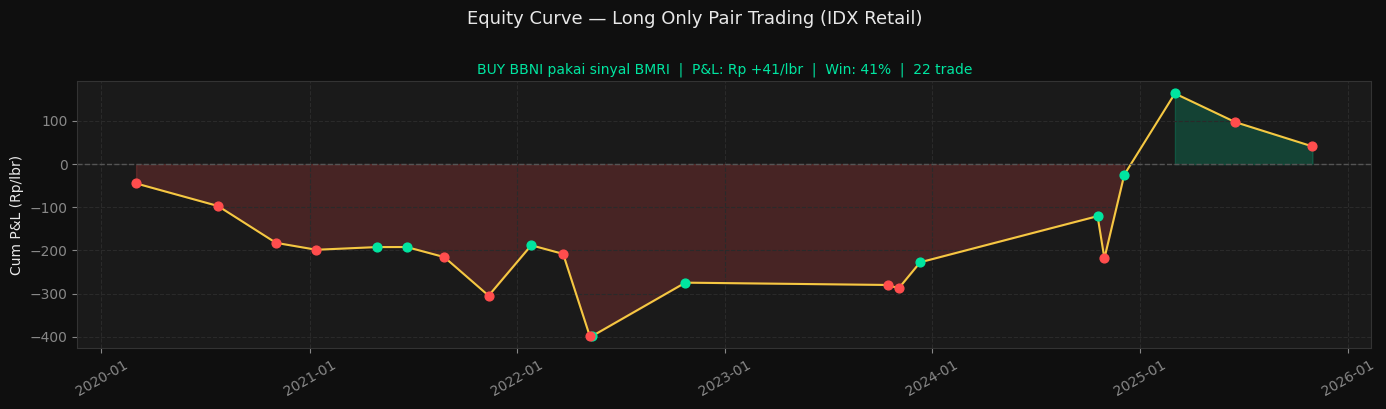

In [9]:
# Equity Curve

n = len(all_bt)
if n == 0:
    print('Tidak ada data')
else:
    fig, axes = plt.subplots(n, 1, figsize=(14, 4*n))
    if n == 1: axes = [axes]

    for ax, ((ta,tb), df_bt) in zip(axes, all_bt.items()):
        la, lb = ta.replace('.JK',''), tb.replace('.JK','')
        if df_bt.empty:
            ax.set_title(f'{la}/{lb} — tidak ada trade', color='#aaa'); continue

        x   = pd.to_datetime(df_bt['exit_date'])
        cum = df_bt['cum_pnl'].values

        ax.fill_between(x, cum, 0, where=cum>=0, alpha=0.2, color='#00e5a0')
        ax.fill_between(x, cum, 0, where=cum<0,  alpha=0.2, color='#ff4d4d')
        ax.plot(x, cum, color='#f5c842', lw=1.5)
        ax.axhline(0, color='#555', lw=1, ls='--')
        w = df_bt[df_bt['net_pnl']>0]
        l = df_bt[df_bt['net_pnl']<0]
        ax.scatter(pd.to_datetime(w['exit_date']), w['cum_pnl'], color='#00e5a0', s=40, zorder=5)
        ax.scatter(pd.to_datetime(l['exit_date']), l['cum_pnl'], color='#ff4d4d', s=40, zorder=5)

        wr    = (df_bt['net_pnl']>0).mean()*100
        total = cum[-1] if len(cum)>0 else 0
        ax.set_title(
            f'BUY {la} pakai sinyal {lb}  |  P&L: Rp {total:+,.0f}/lbr  |  Win: {wr:.0f}%  |  {len(df_bt)} trade',
            fontsize=10, color='#00e5a0' if total >= 0 else '#ff4d4d'
        )
        ax.set_ylabel('Cum P&L (Rp/lbr)'); ax.grid(True)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

    plt.suptitle('Equity Curve — Long Only Pair Trading (IDX Retail)',
                 fontsize=13, color='#e8e8e8', y=1.01)
    plt.tight_layout(); plt.show()

In [10]:
# Trade History

for (ta,tb), df_bt in all_bt.items():
    la, lb = ta.replace('.JK',''), tb.replace('.JK','')
    if df_bt.empty: continue
    print(f'\n{"="*60}')
    print(f'  {la} / {lb} — {len(df_bt)} trade  (Beli {la}, sinyal dari spread dengan {lb})')
    print(f'{"="*60}')
    display(df_bt[[
        'entry_date','exit_date','hold_days',
        'entry_price','exit_price',
        'entry_z','exit_z',
        'return_%','net_pnl','cum_pnl','hasil'
    ]].rename(columns={
        'entry_date':'Tanggal Beli', 'exit_date':'Tanggal Jual',
        'hold_days':'Hold(hr)',
        'entry_price':f'Harga Beli {la}', 'exit_price':f'Harga Jual {la}',
        'entry_z':'Z Beli', 'exit_z':'Z Jual',
        'return_%':'Return%', 'net_pnl':'P&L Bersih',
        'cum_pnl':'P&L Kumulatif', 'hasil':''
    }))


  BBNI / BMRI — 22 trade  (Beli BBNI, sinyal dari spread dengan BMRI)


,Tanggal Beli,Tanggal Jual,Hold(hr),Harga Beli BBNI,Harga Jual BBNI,Z Beli,Z Jual,Return%,P&L Bersih,P&L Kumulatif,
0,2020-02-28,2020-03-02,3,2790.0,2761.0,-3.034,2.436,-1.61,-44.8,-44.8,❌
1,2020-07-23,2020-07-24,1,1927.0,1886.0,-2.109,-0.000,-2.72,-52.3,-97.1,❌
2,2020-10-26,2020-11-03,8,1984.0,1911.0,-2.177,0.032,-4.30,-85.3,-182.5,❌
3,2021-01-11,2021-01-13,2,2669.0,2669.0,-2.520,0.417,-0.60,-16.0,-198.5,❌
4,2021-04-28,2021-04-29,1,2401.0,2422.0,-2.267,0.308,0.26,6.1,-192.3,✅
5,2021-06-18,2021-06-21,3,2037.0,2049.0,-3.442,2.194,0.01,0.1,-192.2,✅
6,2021-08-25,2021-08-26,1,2164.0,2154.0,-2.238,0.768,-1.07,-23.3,-215.5,❌
7,2021-11-10,2021-11-12,2,2917.0,2845.0,-2.037,-0.197,-3.07,-89.4,-304.9,❌
8,2022-01-25,2022-01-26,1,2803.0,2937.0,-2.323,0.784,4.17,116.8,-188.1,✅
9,2022-03-21,2022-03-23,2,3329.0,3329.0,-2.722,-0.456,-0.60,-20.0,-208.1,❌


  RINGKASAN PERFORMA


,Pair,Trade,Win Rate,Total Return,Sharpe,Max DD (Rp),Max DD %,Calmar,Win Streak,Lose Streak
0,BBNI/BMRI,22,40.9%,-3.2%,-0.79 🔴 Poor,Rp -354,790.2% 🔴 Parah,0.00,2,4



  Sharpe > 1.0 = bagus  |  > 2.0 = sangat bagus
  Calmar > 1.0 = return > risiko drawdown
  DD%    makin kecil makin aman


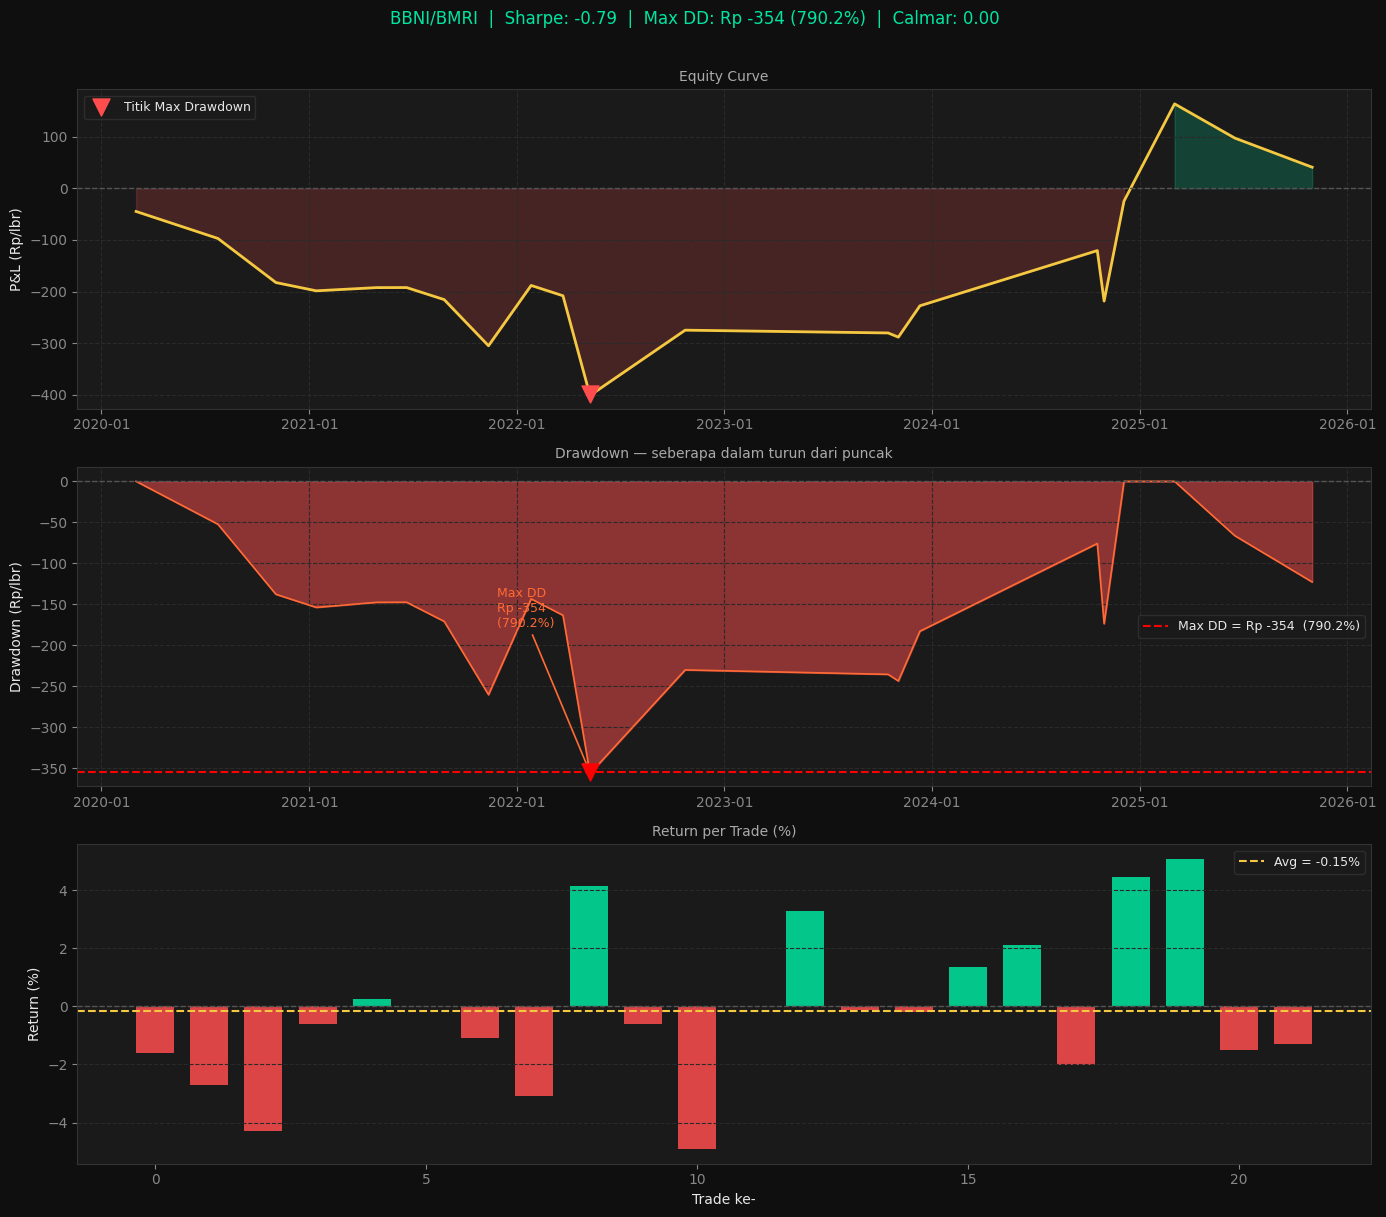

  ── BBNI/BMRI ──────────────────────────────────
  Sharpe : -0.79  🔴 Poor
    Tiap 1 unit risiko, lo dapat -0.79 unit return
  Max DD : Rp -354/lbr  (790.2%)  🔴 Parah
    Worst case equity pernah turun 790.2% dari puncaknya
  Calmar : 0.00  (return -3.2% vs DD 790.2%)
  Recover: 8 trade setelah max drawdown
  Streak : max 2x menang / 4x kalah berturut



In [11]:
# SHARPE RATIO & MAX DRAWDOWN

import itertools

RISK_FREE_RATE = 0.06
metrics = []

for (ta, tb), df_bt in all_bt.items():
    la, lb = ta.replace('.JK',''), tb.replace('.JK','')
    if df_bt.empty: continue

    returns   = df_bt['return_%'].values / 100
    cum       = df_bt['cum_pnl'].values
    hold_days = df_bt['hold_days'].values

    # Sharpe Ratio
    avg_hold_yr  = hold_days.mean() / 252
    rf_per_trade = RISK_FREE_RATE * avg_hold_yr
    excess  = returns - rf_per_trade
    sharpe  = (excess.mean() / excess.std() * np.sqrt(252 / hold_days.mean())) if excess.std() > 0 else 0

    # Max Drawdown
    peak       = np.maximum.accumulate(cum)
    dd         = cum - peak
    max_dd     = dd.min()
    max_dd_i   = dd.argmin()
    peak_i     = np.argmax(cum[:max_dd_i+1]) if max_dd_i > 0 else 0
    max_dd_pct = (max_dd / cum[peak_i] * 100) if cum[peak_i] != 0 else 0

    # Recovery
    after_dd  = cum[max_dd_i:]
    recovered = np.where(after_dd >= cum[peak_i])[0]
    recovery  = recovered[0] if len(recovered) > 0 else None

    # Calmar
    total_ret_pct = df_bt['return_%'].sum()
    calmar = abs(total_ret_pct / max_dd_pct) if max_dd_pct != 0 else float('inf')

    # Streak
    hasil    = (df_bt['net_pnl'] > 0).astype(int).values
    max_win  = max((sum(1 for _ in g) for k,g in itertools.groupby(hasil) if k==1), default=0)
    max_lose = max((sum(1 for _ in g) for k,g in itertools.groupby(hasil) if k==0), default=0)

    metrics.append({
        'pair': f'{la}/{lb}', 'label_a': la, 'label_b': lb,
        'ta': ta, 'tb': tb,
        'n_trades': len(df_bt),
        'win_rate': (df_bt['net_pnl']>0).mean() * 100,
        'total_return_pct': total_ret_pct,
        'sharpe': sharpe,
        'max_dd': max_dd, 'max_dd_pct': max_dd_pct,
        'calmar': calmar,
        'max_win_streak': max_win, 'max_lose_streak': max_lose,
        'avg_hold': hold_days.mean(),
        'cum': cum, 'dd': dd,
        'exit_dates': pd.to_datetime(df_bt['exit_date']),
        'returns_pct': df_bt['return_%'].values,
        'recovery': recovery,
    })

def sharpe_label(s):
    if s >= 2.0: return '🟢 Excellent'
    elif s >= 1.0: return '🟡 Good'
    elif s >= 0.5: return '🟠 Acceptable'
    else: return '🔴 Poor'

def dd_label(pct):
    if abs(pct) <= 10: return '🟢 Ringan'
    elif abs(pct) <= 25: return '🟡 Sedang'
    elif abs(pct) <= 50: return '🟠 Berat'
    else: return '🔴 Parah'

# Tabel ringkasan
print('='*70)
print('  RINGKASAN PERFORMA')
print('='*70)
rows = []
for m in metrics:
    rows.append({
        'Pair'         : m['pair'],
        'Trade'        : m['n_trades'],
        'Win Rate'     : f"{m['win_rate']:.1f}%",
        'Total Return' : f"{m['total_return_pct']:+.1f}%",
        'Sharpe'       : f"{m['sharpe']:.2f}  {sharpe_label(m['sharpe'])}",
        'Max DD (Rp)'  : f"Rp {m['max_dd']:,.0f}",
        'Max DD %'     : f"{m['max_dd_pct']:.1f}%  {dd_label(m['max_dd_pct'])}",
        'Calmar'       : f"{m['calmar']:.2f}",
        'Win Streak'   : m['max_win_streak'],
        'Lose Streak'  : m['max_lose_streak'],
    })
display(pd.DataFrame(rows))
print()
print('  Sharpe > 1.0 = bagus  |  > 2.0 = sangat bagus')
print('  Calmar > 1.0 = return > risiko drawdown')
print('  DD%    makin kecil makin aman')
for m in metrics:
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
    fig.suptitle(
        f"{m['pair']}  |  Sharpe: {m['sharpe']:.2f}  |  Max DD: Rp {m['max_dd']:,.0f} ({m['max_dd_pct']:.1f}%)  |  Calmar: {m['calmar']:.2f}",
        fontsize=12, color='#00e5a0', y=1.01
    )

    x   = m['exit_dates']
    cum = m['cum']
    dd  = m['dd']
    dd_idx = np.argmin(dd)

    # Equity Curve
    ax1.fill_between(x, cum, 0, where=cum>=0, alpha=0.2, color='#00e5a0')
    ax1.fill_between(x, cum, 0, where=cum<0,  alpha=0.2, color='#ff4d4d')
    ax1.plot(x, cum, color='#f5c842', lw=2)
    ax1.axhline(0, color='#555', lw=1, ls='--')
    ax1.scatter([x.iloc[dd_idx]], [cum[dd_idx]], color='#ff4d4d',
                s=150, zorder=6, marker='v', label='Titik Max Drawdown')
    ax1.set_title('Equity Curve', fontsize=10, color='#aaa')
    ax1.set_ylabel('P&L (Rp/lbr)')
    ax1.legend(fontsize=9, facecolor='#1a1a1a', edgecolor='#333')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.grid(True)

    # Drawdown
    ax2.fill_between(x, dd, 0, alpha=0.5, color='#ff4d4d')
    ax2.plot(x, dd, color='#ff6b35', lw=1.2)
    ax2.axhline(0, color='#555', lw=1, ls='--')
    ax2.axhline(m['max_dd'], color='#ff0000', lw=1.5, ls='--',
                label=f"Max DD = Rp {m['max_dd']:,.0f}  ({m['max_dd_pct']:.1f}%)")
    ax2.scatter([x.iloc[dd_idx]], [dd[dd_idx]], color='#ff0000', s=150, zorder=6, marker='v')
    ax2.annotate(
        f"  Max DD\n  Rp {m['max_dd']:,.0f}\n  ({m['max_dd_pct']:.1f}%)",
        xy=(x.iloc[dd_idx], dd[dd_idx]),
        xytext=(x.iloc[max(0, dd_idx-3)], dd[dd_idx] * 0.5),
        color='#ff6b35', fontsize=9,
        arrowprops=dict(arrowstyle='->', color='#ff6b35', lw=1.2)
    )
    ax2.set_title('Drawdown — seberapa dalam turun dari puncak', fontsize=10, color='#aaa')
    ax2.set_ylabel('Drawdown (Rp/lbr)')
    ax2.legend(fontsize=9, facecolor='#1a1a1a', edgecolor='#333')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax2.grid(True)

    # Return per Trade (bar)
    rp    = m['returns_pct']
    cols  = ['#00e5a0' if r > 0 else '#ff4d4d' for r in rp]
    ax3.bar(range(len(rp)), rp, color=cols, alpha=0.85, width=0.7)
    ax3.axhline(0, color='#555', lw=1, ls='--')
    ax3.axhline(rp.mean(), color='#f5c842', lw=1.5, ls='--',
                label=f'Avg = {rp.mean():+.2f}%')
    ax3.set_title('Return per Trade (%)', fontsize=10, color='#aaa')
    ax3.set_ylabel('Return (%)')
    ax3.set_xlabel('Trade ke-')
    ax3.legend(fontsize=9, facecolor='#1a1a1a', edgecolor='#333')
    ax3.grid(True, axis='y')

    plt.tight_layout()
    plt.show()

    # Summary teks
    rec = f"{m['recovery']} trade" if m['recovery'] is not None else 'belum recover sampai akhir data'
    print(f"  ── {m['pair']} ──────────────────────────────────")
    print(f"  Sharpe : {m['sharpe']:.2f}  {sharpe_label(m['sharpe'])}")
    print(f"    Tiap 1 unit risiko, lo dapat {m['sharpe']:.2f} unit return")
    print(f"  Max DD : Rp {m['max_dd']:,.0f}/lbr  ({m['max_dd_pct']:.1f}%)  {dd_label(m['max_dd_pct'])}")
    print(f"    Worst case equity pernah turun {abs(m['max_dd_pct']):.1f}% dari puncaknya")
    print(f"  Calmar : {m['calmar']:.2f}  (return {m['total_return_pct']:+.1f}% vs DD {abs(m['max_dd_pct']):.1f}%)")
    print(f"  Recover: {rec} setelah max drawdown")
    print(f"  Streak : max {m['max_win_streak']}x menang / {m['max_lose_streak']}x kalah berturut")
    print()

In [12]:
#signal gen
# GANTI INI
MODAL = 10_000_000
LOT   = 100

print('='*62)
print('  SINYAL HARI INI — LONG ONLY PAIR TRADING')
print('='*62)

for (ta, tb), r in results.items():
    la, lb   = ta.replace('.JK',''), tb.replace('.JK','')
    harga_a  = float(r['pa'].iloc[-1])
    harga_b  = float(r['pb'].iloc[-1])
    hr       = r['hr']
    z_skrg   = float(r['zs'].iloc[-1])
    sp       = r['sp']
    sig      = r['sig']

    roll_mean = float(sp.rolling(ZSCORE_WINDOW).mean().iloc[-1])
    roll_std  = float(sp.rolling(ZSCORE_WINDOW).std().iloc[-1])


    ic = r['ic']
    target_a  = roll_mean + hr * harga_b + ic
    stop_a    = (roll_mean - 3*roll_std) + hr * harga_b + ic  # stop di z = -3
    entry_a   = (roll_mean - ENTRY_THRESHOLD*roll_std) + hr * harga_b + ic

    posisi_skrg    = sig['position'].iloc[-1]
    posisi_kemarin = sig['position'].iloc[-2]
    is_entry = (posisi_kemarin == 0 and posisi_skrg == 1)
    is_exit  = (posisi_kemarin == 1 and posisi_skrg == 0)

    lot          = max(1, int(MODAL / (harga_a * LOT)))
    modal_pakai  = lot * harga_a * LOT
    est_profit   = lot * (target_a - harga_a) * LOT
    est_loss     = lot * (stop_a - harga_a) * LOT
    rr           = abs(target_a - harga_a) / abs(harga_a - stop_a) if abs(harga_a - stop_a) > 0 else 0

    print(f'\nPair    : {la} / {lb}  (p-value: {r["pval"]:.4f}  |  β: {hr:.4f})')
    print(f'Harga   : {la} = Rp {harga_a:,.0f}  |  {lb} = Rp {harga_b:,.0f}')
    print(f'Z-Score : {z_skrg:.3f}', end='  ')
    if   z_skrg <= -ENTRY_THRESHOLD: print(f'← 🟢 ZONA BUY {la}')
    elif z_skrg >= -EXIT_THRESHOLD:  print(f'← 🟡 ZONA JUAL {la}')
    else: print(f'← ⏳ TUNGGU')

    if is_entry:
        print(f'\n  🟢 BUY — {la} lagi MURAH relatif ke {lb}')
        print(f'     Aksi   : BUY {lot} lot {la} @ Rp {harga_a:,.0f}')
        print(f'     Modal  : Rp {modal_pakai:,.0f}')
        print(f'     ─────────────────────────────────────────')
        print(f'     ✅ JUAL kalau {la} naik ke  : Rp {target_a:,.0f}  (spread balik normal)')
        print(f'        Est. profit              : Rp {est_profit:+,.0f}')
        print(f'     ❌ STOP kalau {la} turun ke : Rp {stop_a:,.0f}')
        print(f'        Est. loss                : Rp {est_loss:+,.0f}')
        print(f'     📊 Risk/Reward              : 1 : {rr:.1f}')

    elif is_exit:
        entry_rows = sig[(sig['position']==1)&(sig['position'].shift(1)==0)]
        if len(entry_rows) > 0:
            ep     = float(r['pa'].loc[entry_rows.index[-1]])
            pnl    = (harga_a - ep) * lot * LOT
            print(f'\n  🏁 JUAL — spread sudah balik normal')
            print(f'     Beli dulu  : @ Rp {ep:,.0f}')
            print(f'     Jual skrg  : @ Rp {harga_a:,.0f}')
            print(f'     P&L total  : Rp {pnl:+,.0f}  ({lot} lot)')

    elif posisi_skrg == 1:
        entry_rows = sig[(sig['position']==1)&(sig['position'].shift(1)==0)]
        if len(entry_rows) > 0:
            ep     = float(r['pa'].loc[entry_rows.index[-1]])
            e_date = entry_rows.index[-1].strftime('%Y-%m-%d')
            upnl   = (harga_a - ep) * lot * LOT
            icon   = '📈' if upnl >= 0 else '📉'
            print(f'\n  ⏳ HOLD — {la} (beli {e_date} @ Rp {ep:,.0f})')
            print(f'     P&L skrg   : {icon} Rp {upnl:+,.0f}  (unrealized, {lot} lot)')
            print(f'     ✅ JUAL di : Rp {target_a:,.0f}  (z balik ke -{EXIT_THRESHOLD})')
            print(f'     ❌ STOP di : Rp {stop_a:,.0f}  (z tembus -3)')

    else:
        print(f'\n  ⚪ FLAT — belum ada sinyal')
        print(f'     BUY kalau {la} turun ke zona : Rp {entry_a:,.0f}  (z = -{ENTRY_THRESHOLD})')
        print(f'     (asumsi {lb} tetap di Rp {harga_b:,.0f})')
        if z_skrg <= -1.5:
            print(f'     ⚠️  Z-Score {z_skrg:.2f} — mendekati zona BUY, pantau terus!')

    print('-'*62)

  SINYAL HARI INI — LONG ONLY PAIR TRADING

Pair    : BBNI / BMRI  (p-value: 0.0100  |  β: 0.8340)
Harga   : BBNI = Rp 4,400  |  BMRI = Rp 5,275
Z-Score : -0.077  ← 🟡 ZONA JUAL BBNI

  ⚪ FLAT — belum ada sinyal
     BUY kalau BBNI turun ke zona : Rp 4,400  (z = -2.0)
     (asumsi BMRI tetap di Rp 5,275)
--------------------------------------------------------------
